# Acquisition SCR Fear-Learning Definitions

This notebook identifies physiological SCR responders and fear-learning subgroups from phase-1 acquisition SCR. The logic is intentionally organized as:

1. **Describe** the SCR file, acquisition trial structure, and scored SCR distribution.
2. **Diagnose** habituation, floor effects, and subject-level low-response structure.
3. **Define** physiological responders and SCR-defined learner groups for sensitivity analyses.

Primary neural MVPA analyses should retain all participants. SCR-defined responder/learner groups are intended for sensitivity analyses, not for replacing the full-sample neural analyses.

## 1. Setup

SCR scoring plan: trial-wise amplitudes are scored from raw base-to-peak responses (`phaBase2Peak`). Negative responses and responses below **0.02 uS** are coded as zero, then square-root transformed. Physiological SCR responders are participants with at least **two acquisition CS+ trials** with raw SCR >= **0.05 uS**.

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 160)
sns.set_theme(style="whitegrid", context="talk")

SCR_PATH = Path("/Users/xiaoqianxiao/projects/NARSAD/EDR/peak_stats_table-phase1.csv")
META_PATH = Path("/Users/xiaoqianxiao/projects/NARSAD/MRI/source_data/behav/drug_order.csv")
OUT_DIR = Path("/Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCR_RAW_COL = "phaBase2Peak"
SCR_THRESHOLDED_COL = "phaBase2Peak_thresholded_0p02"
SCR_SCORE_COL = "sqrt_phaBase2Peak"
BAD_COL = "bad"

TRIAL_RESPONSE_THRESHOLD_RAW = 0.02
PHYSIOLOGICAL_RESPONDER_THRESHOLD_RAW = 0.05
PHYSIOLOGICAL_RESPONDER_MIN_CSPLUS_TRIALS = 2
LOW_RESPONDER_RATE = 0.25
NEAR_NONRESPONDER_RATE = 0.10
WINDOW_N = 4
ACQUISITION_TRIAL_MIN = 1
ACQUISITION_TRIAL_MAX = 24

CONDITION_ORDER = ["CS-", "CSS", "CSR"]
CONDITION_PALETTE = {"CS-": "#4C72B0", "CSS": "#C44E52", "CSR": "#DD8452"}
GROUP_PALETTE = {"HC": "#4C72B0", "SAD": "#C44E52"}

print("SCR_PATH:", SCR_PATH)
print("META_PATH:", META_PATH, "exists=", META_PATH.exists())
print("OUT_DIR:", OUT_DIR)
print("SCR raw column:", SCR_RAW_COL)
print("SCR score:", f"sqrt(raw) after raw < {TRIAL_RESPONSE_THRESHOLD_RAW} uS is coded zero")
print("Physiological responder:", f">= {PHYSIOLOGICAL_RESPONDER_MIN_CSPLUS_TRIALS} CS+ trials with raw SCR >= {PHYSIOLOGICAL_RESPONDER_THRESHOLD_RAW} uS")


def save_current_fig(name, dpi=180):
    path = OUT_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved figure ->", path)
    return path


def safe_percent(n, d):
    return 100 * n / d if d else np.nan


def summarize_numeric(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    if x.empty:
        return {"n": 0, "mean": np.nan, "median": np.nan, "p25": np.nan, "p75": np.nan, "min": np.nan, "max": np.nan}
    return {"n": int(x.size), "mean": float(x.mean()), "median": float(x.median()), "p25": float(x.quantile(0.25)), "p75": float(x.quantile(0.75)), "min": float(x.min()), "max": float(x.max())}


SCR_PATH: /Users/xiaoqianxiao/projects/NARSAD/EDR/peak_stats_table-phase1.csv
META_PATH: /Users/xiaoqianxiao/projects/NARSAD/MRI/source_data/behav/drug_order.csv exists= True
OUT_DIR: /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial
SCR raw column: phaBase2Peak
SCR score: sqrt(raw) after raw < 0.02 uS is coded zero
Physiological responder: >= 2 CS+ trials with raw SCR >= 0.05 uS


## 2. Describe The Acquisition SCR Data

This section loads phase-1 acquisition SCR, maps stimulus labels to `CS-`, `CSS`, and `CSR`, and creates the thresholded square-root SCR score used for learner definitions.

In [10]:
scr = pd.read_csv(SCR_PATH)
required = {"sid", "stTy", "stNum", SCR_RAW_COL}
missing = sorted(required - set(scr.columns))
if missing:
    raise ValueError(f"SCR file is missing required columns: {missing}")

scr = scr.copy()
scr["Subject"] = scr["sid"].astype(str).str.strip()
scr["stNum"] = pd.to_numeric(scr["stNum"], errors="coerce")
scr[SCR_RAW_COL] = pd.to_numeric(scr[SCR_RAW_COL], errors="coerce")
scr[SCR_THRESHOLDED_COL] = np.where(scr[SCR_RAW_COL] >= TRIAL_RESPONSE_THRESHOLD_RAW, scr[SCR_RAW_COL], 0.0)
scr[SCR_SCORE_COL] = np.sqrt(scr[SCR_THRESHOLDED_COL])
scr["Condition"] = scr["stTy"].replace({"CS+S": "CSS", "CS+R": "CSR", "CS-": "CS-"})
scr["Domain"] = np.where(scr["Condition"].isin(["CSS", "CSR"]), "CS+", "CS-")

n_raw = len(scr)
if BAD_COL in scr.columns:
    scr[BAD_COL] = pd.to_numeric(scr[BAD_COL], errors="coerce").fillna(0).astype(int)
    scr = scr[scr[BAD_COL] == 0].copy()

scr = scr.dropna(subset=["Subject", "Condition", "stNum", SCR_RAW_COL, SCR_THRESHOLDED_COL, SCR_SCORE_COL])
scr = scr[scr["Condition"].isin(CONDITION_ORDER)].copy()
acq = scr[(scr["stNum"] >= ACQUISITION_TRIAL_MIN) & (scr["stNum"] <= ACQUISITION_TRIAL_MAX)].copy()
acq = acq.sort_values(["Subject", "stNum"])
acq["ConditionTrial"] = acq.groupby(["Subject", "Condition"]).cumcount() + 1
acq["Window"] = np.where(acq["ConditionTrial"] <= WINDOW_N, "Early", np.where(acq["ConditionTrial"] > 8 - WINDOW_N, "Late", "Middle"))

print(f"Raw rows: {n_raw}")
print(f"Rows after bad/NA/condition filtering: {len(scr)}")
print(f"Acquisition rows: {len(acq)}")
print(f"Subjects: {acq['Subject'].nunique()}")

print("Trial structure by stNum and condition")
display(pd.crosstab(acq["stNum"], acq["Condition"]))

print("Rows per subject and condition")
subject_condition_counts = acq.groupby(["Subject", "Condition"]).size().unstack(fill_value=0).reindex(columns=CONDITION_ORDER)
display(subject_condition_counts.describe())

print("SCR score distribution")
display(acq[[SCR_RAW_COL, SCR_THRESHOLDED_COL, SCR_SCORE_COL]].describe())


Raw rows: 2496
Rows after bad/NA/condition filtering: 2496
Acquisition rows: 2496
Subjects: 104
Trial structure by stNum and condition


Condition,CS-,CSR,CSS
stNum,,,
1,0,104,0
2,0,0,104
3,104,0,0
4,0,104,0
5,0,0,104
6,0,0,104
7,104,0,0
8,0,0,104
9,0,104,0


Rows per subject and condition


Condition,CS-,CSS,CSR
count,104.0,104.0,104.0
mean,8.0,8.0,8.0
std,0.0,0.0,0.0
min,8.0,8.0,8.0
25%,8.0,8.0,8.0
50%,8.0,8.0,8.0
75%,8.0,8.0,8.0
max,8.0,8.0,8.0


SCR score distribution


,phaBase2Peak,phaBase2Peak_thresholded_0p02,sqrt_phaBase2Peak
count,2496.000000,2496.000000,2496.000000
mean,0.056421,0.054466,0.121837
std,0.131802,0.132535,0.199093
min,-0.012000,0.000000,0.000000
25%,0.001000,0.000000,0.000000
50%,0.005000,0.000000,0.000000
75%,0.046000,0.046000,0.214476
max,1.803000,1.803000,1.342758


## 3. Diagnose Habituation And Floor Effects

Before defining learners, first quantify whether SCR decreases across acquisition and whether late responses approach floor. These diagnostics use raw SCR for floor thresholds and the thresholded square-root SCR for learner-relevant summaries.

Raw SCR floor summary


,Window,Condition,n,mean,median,p25,p75,min,max,pct_raw_le_0,pct_raw_le_0.005,pct_raw_le_0.01,pct_raw_le_0.02,pct_raw_le_0.05,pct_raw_le_0.1
0,Early,CS-,416,0.074673,0.0160,0.002,0.07225,-0.002,1.296,6.009615,37.740385,45.432692,53.846154,70.673077,78.846154
1,Early,CSS,416,0.093267,0.0220,0.001,0.10600,-0.010,1.803,23.076923,37.259615,42.307692,49.759615,61.538462,73.798077
2,Early,CSR,416,0.085510,0.0100,0.000,0.09350,-0.012,1.331,28.605769,43.028846,50.240385,56.009615,66.826923,76.442308
3,Early,CS+,832,0.089388,0.0160,-0.000,0.09850,-0.012,1.803,25.841346,40.144231,46.274038,52.884615,64.182692,75.120192
4,Late,CS-,416,0.024721,0.0045,0.002,0.01700,-0.004,0.430,7.692308,53.125000,66.586538,78.125000,87.740385,92.788462
5,Late,CSS,416,0.027817,0.0010,-0.000,0.01500,-0.007,0.504,42.307692,67.067308,71.875000,78.846154,85.817308,89.903846
6,Late,CSR,416,0.032538,0.0020,-0.000,0.01600,-0.007,0.804,39.423077,62.019231,70.192308,76.923077,83.894231,91.586538
7,Late,CS+,832,0.030178,0.0020,0.000,0.01500,-0.007,0.804,40.865385,64.543269,71.033654,77.884615,84.855769,90.745192
8,All,CS-,832,0.049697,0.0070,0.002,0.03500,-0.004,1.296,6.850962,45.432692,56.009615,65.985577,79.206731,85.817308
9,All,CSS,832,0.060542,0.0040,0.000,0.05525,-0.010,1.803,32.692308,52.163462,57.091346,64.302885,73.677885,81.850962


Subject-level habituation: late minus early


,Condition,n_subjects,mean_raw_late_minus_early,median_raw_late_minus_early,decreased_n,decreased_percent,mean_sqrt_late_minus_early,median_sqrt_late_minus_early
0,CS-,104,-0.049952,-0.016125,87,83.653846,-0.098331,-0.055424
1,CSS,104,-0.065450,-0.025125,87,83.653846,-0.123577,-0.083526
2,CSR,104,-0.052971,-0.015125,79,75.961538,-0.094884,-0.065238


Saved figure -> /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_phase1_habituation_subject_trajectories_raw.png


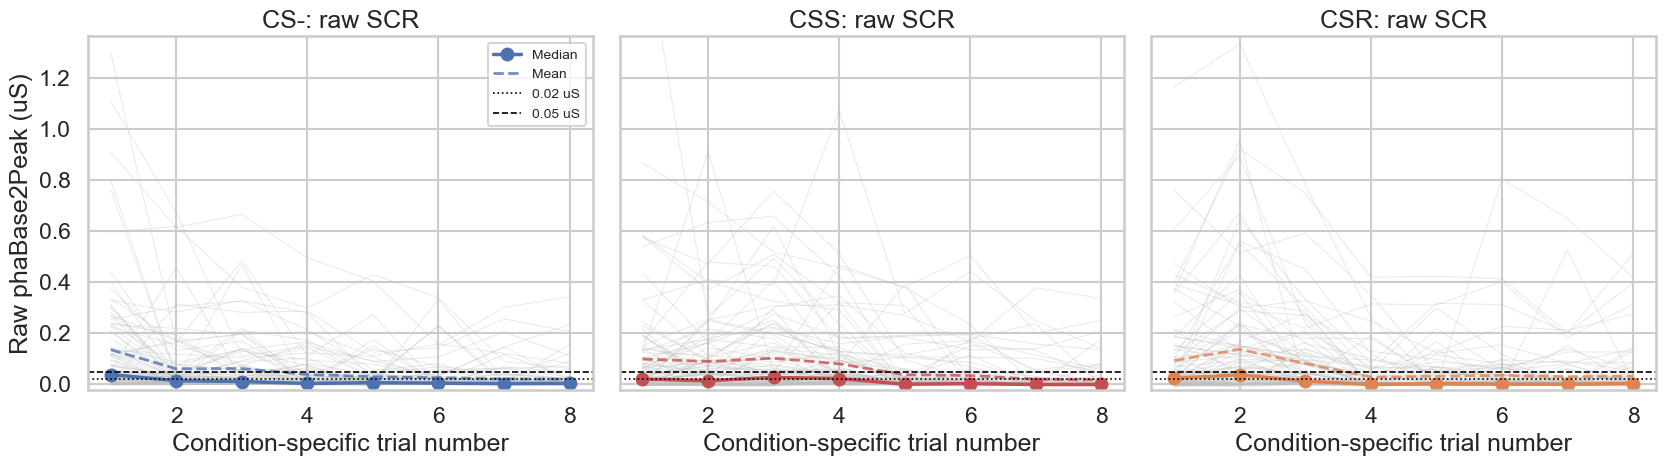

/var/folders/63/3j_hstl96w58qx1sdw9czhxr0000gn/T/ipykernel_9552/2351931464.py:63: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.25'` for the same effect.

  sns.stripplot(data=plot_df.sample(min(len(plot_df), 1200), random_state=10), x="Condition", y=SCR_RAW_COL, hue="Window", order=CONDITION_ORDER, dodge=True, alpha=0.18, size=2, color="0.25", ax=ax)


Saved figure -> /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_phase1_habituation_early_late_distributions.png


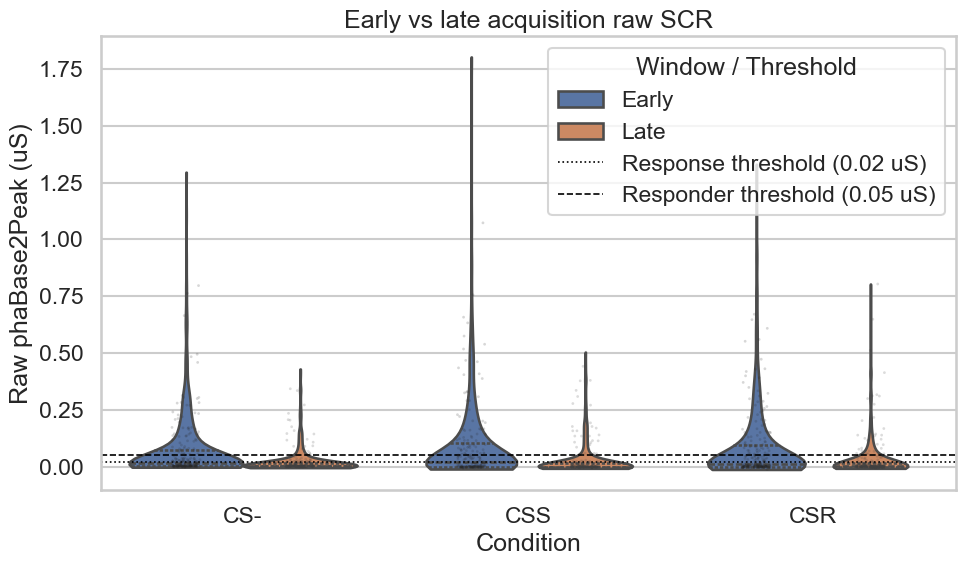

In [11]:
floor_thresholds = [0, 0.005, 0.01, 0.02, 0.05, 0.10]
window_order = ["Early", "Late", "All"]
floor_rows = []
for window in window_order:
    for condition in CONDITION_ORDER + ["CS+"]:
        if window == "All":
            sub = acq.copy()
        else:
            sub = acq[acq["Window"] == window].copy()
        if condition == "CS+":
            sub = sub[sub["Domain"] == "CS+"]
        else:
            sub = sub[sub["Condition"] == condition]
        stats_row = summarize_numeric(sub[SCR_RAW_COL])
        row = {"Window": window, "Condition": condition, **stats_row}
        for thr in floor_thresholds:
            row[f"pct_raw_le_{thr:g}"] = safe_percent(int((sub[SCR_RAW_COL] <= thr).sum()), len(sub))
        floor_rows.append(row)
floor_summary = pd.DataFrame(floor_rows)
print("Raw SCR floor summary")
display(floor_summary)
hab_rows = []
for condition in CONDITION_ORDER:
    wide_raw = acq.pivot_table(index="Subject", columns=["Condition", "Window"], values=SCR_RAW_COL, aggfunc="mean")
    wide_sqrt = acq.pivot_table(index="Subject", columns=["Condition", "Window"], values=SCR_SCORE_COL, aggfunc="mean")
    raw_change = wide_raw[(condition, "Late")] - wide_raw[(condition, "Early")]
    sqrt_change = wide_sqrt[(condition, "Late")] - wide_sqrt[(condition, "Early")]
    hab_rows.append({
        "Condition": condition,
        "n_subjects": int(raw_change.notna().sum()),
        "mean_raw_late_minus_early": float(raw_change.mean()),
        "median_raw_late_minus_early": float(raw_change.median()),
        "decreased_n": int((raw_change < 0).sum()),
        "decreased_percent": safe_percent(int((raw_change < 0).sum()), int(raw_change.notna().sum())),
        "mean_sqrt_late_minus_early": float(sqrt_change.mean()),
        "median_sqrt_late_minus_early": float(sqrt_change.median()),
    })
habituation_summary = pd.DataFrame(hab_rows)
print("Subject-level habituation: late minus early")
display(habituation_summary)
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, condition in zip(axes, CONDITION_ORDER):
    sub = acq[acq["Condition"] == condition].copy()
    for _, g in sub.groupby("Subject"):
        ax.plot(g["ConditionTrial"], g[SCR_RAW_COL], color="0.75", lw=0.7, alpha=0.35)
    med = sub.groupby("ConditionTrial")[SCR_RAW_COL].median()
    mean = sub.groupby("ConditionTrial")[SCR_RAW_COL].mean()
    ax.plot(med.index, med.values, marker="o", lw=2.5, color=CONDITION_PALETTE[condition], label="Median")
    ax.plot(mean.index, mean.values, ls="--", lw=2.0, color=CONDITION_PALETTE[condition], alpha=0.8, label="Mean")
    ax.axhline(TRIAL_RESPONSE_THRESHOLD_RAW, color="black", lw=1.2, ls=":", label="0.02 uS" if condition == "CS-" else None)
    ax.axhline(PHYSIOLOGICAL_RESPONDER_THRESHOLD_RAW, color="black", lw=1.2, ls="--", label="0.05 uS" if condition == "CS-" else None)
    ax.set_title(f"{condition}: raw SCR")
    ax.set_xlabel("Condition-specific trial number")
    ax.set_ylim(bottom=min(-0.02, acq[SCR_RAW_COL].min() - 0.01))
axes[0].set_ylabel("Raw phaBase2Peak (uS)")
axes[0].legend(fontsize=10)
plt.tight_layout()
save_current_fig("scr_phase1_habituation_subject_trajectories_raw.png")
plt.show()
plot_df = acq[acq["Window"].isin(["Early", "Late"])].copy()
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=plot_df, x="Condition", y=SCR_RAW_COL, hue="Window", order=CONDITION_ORDER, inner="quartile", cut=0, ax=ax)
sns.stripplot(data=plot_df.sample(min(len(plot_df), 1200), random_state=10), x="Condition", y=SCR_RAW_COL, hue="Window", order=CONDITION_ORDER, dodge=True, alpha=0.18, size=2, color="0.25", ax=ax)
line_002 = ax.axhline(TRIAL_RESPONSE_THRESHOLD_RAW, color="black", lw=1.2, ls=":", label="Response threshold (0.02 uS)")
line_005 = ax.axhline(PHYSIOLOGICAL_RESPONDER_THRESHOLD_RAW, color="black", lw=1.2, ls="--", label="Responder threshold (0.05 uS)")
handles, labels = ax.get_legend_handles_labels()
seen = set()
unique_handles = []
unique_labels = []
for handle, label in zip(handles, labels):
    if label not in seen and label not in {"_nolegend_"}:
        seen.add(label)
        unique_handles.append(handle)
        unique_labels.append(label)
ax.legend(unique_handles, unique_labels, title="Window / Threshold", loc="upper right")
ax.set_title("Early vs late acquisition raw SCR")
ax.set_ylabel("Raw phaBase2Peak (uS)")
plt.tight_layout()
save_current_fig("scr_phase1_habituation_early_late_distributions.png")
plt.show()


## 4. Statistical Evidence For Habituation And Floor Effects

These tests quantify the visual/descriptive pattern above. The key question is whether late acquisition responses are significantly lower than early acquisition responses, and whether the fraction of near-floor trials increases late in acquisition. Tests are paired within subject.

Paired early-vs-late SCR tests. One-sided tests ask whether late < early.


,Condition,Measure,N,Early_mean,Late_mean,Late_minus_Early_mean,Late_minus_Early_median,Paired_t,Paired_t_p_one_sided_late_less_early,Wilcoxon_W,Wilcoxon_p_one_sided_late_less_early,Cohen_dz_late_minus_early
0,CS-,phaBase2Peak,104,0.074673,0.024721,-0.049952,-0.016125,-6.047368,1.195417e-08,372.0,1.641996e-14,-0.592993
1,CSS,phaBase2Peak,104,0.093267,0.027817,-0.065450,-0.025125,-5.792946,3.789221e-08,394.0,1.791044e-14,-0.568045
2,CSR,phaBase2Peak,104,0.085510,0.032538,-0.052971,-0.015125,-5.657719,6.931910e-08,673.0,1.274221e-11,-0.554785
3,CS-,sqrt_phaBase2Peak,104,0.160658,0.062327,-0.098331,-0.055424,-8.864665,1.227098e-14,101.5,1.629666e-13,-0.869252
4,CSS,sqrt_phaBase2Peak,104,0.192241,0.068664,-0.123577,-0.083526,-8.404385,1.267292e-13,89.5,2.467395e-13,-0.824118
5,CSR,sqrt_phaBase2Peak,104,0.171007,0.076123,-0.094884,-0.065238,-7.402751,1.879937e-11,172.0,4.620611e-11,-0.725899


Paired early-vs-late response-rate/floor-rate tests. One-sided tests ask whether response rate decreases and floor rate increases late.


,Condition,Threshold_uS,N,Early_response_rate_mean,Late_response_rate_mean,Response_rate_late_minus_early,Response_rate_t,Response_rate_t_p_one_sided_late_less_early,Response_rate_Wilcoxon_p_one_sided_late_less_early,Early_floor_rate_mean,Late_floor_rate_mean,Floor_rate_late_minus_early,Floor_rate_t,Floor_rate_t_p_one_sided_late_greater_early,Floor_rate_Wilcoxon_p_one_sided_late_greater_early
0,CS-,0.02,104,46.153846,21.875000,-24.278846,-7.688386,4.584677e-12,2.592341e-10,53.846154,78.125000,24.278846,7.688386,4.584677e-12,2.592341e-10
1,CSS,0.02,104,50.240385,21.153846,-29.086538,-8.969835,7.182296e-15,9.269218e-12,49.759615,78.846154,29.086538,8.969835,7.182296e-15,9.269218e-12
2,CSR,0.02,104,43.990385,23.076923,-20.913462,-7.364342,2.270295e-11,3.517392e-09,56.009615,76.923077,20.913462,7.364342,2.270295e-11,3.517392e-09
3,CS-,0.05,104,29.326923,12.259615,-17.067308,-6.978101,1.489668e-10,4.772885e-09,70.673077,87.740385,17.067308,6.978101,1.489668e-10,4.772885e-09
4,CSS,0.05,104,38.461538,14.182692,-24.278846,-7.923684,1.420066e-12,1.521109e-10,61.538462,85.817308,24.278846,7.923684,1.420066e-12,1.521109e-10
5,CSR,0.05,104,33.173077,16.105769,-17.067308,-5.759044,4.411430e-08,1.863034e-07,66.826923,83.894231,17.067308,5.759044,4.411430e-08,1.863034e-07


Saved figure -> /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_phase1_habituation_floor_effect_statistics.png


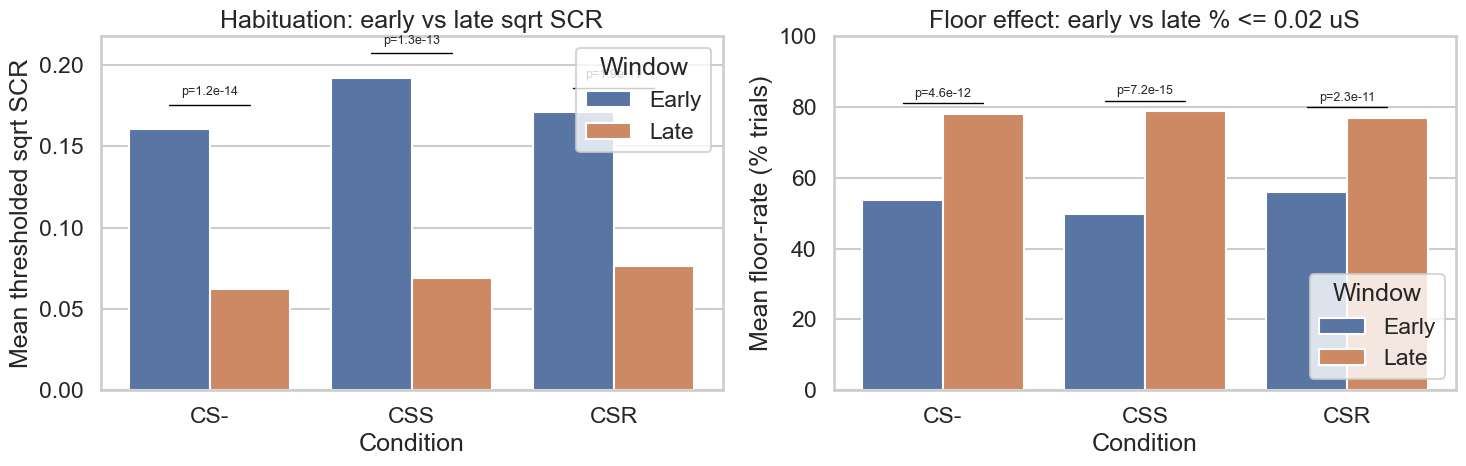

In [12]:
def paired_early_late_stats(df, value_col, condition, alternative="less"):
    sub = df[df["Condition"] == condition].copy()
    means = sub[sub["Window"].isin(["Early", "Late"])].pivot_table(index="Subject", columns="Window", values=value_col, aggfunc="mean")
    paired = means[["Early", "Late"]].dropna()
    early = paired["Early"].to_numpy(dtype=float)
    late = paired["Late"].to_numpy(dtype=float)
    diff = late - early
    if len(diff) < 2:
        return {}
    t_res = stats.ttest_rel(late, early, alternative=alternative)
    try:
        w_res = stats.wilcoxon(late, early, alternative=alternative, zero_method="wilcox")
        w_stat, w_p = float(w_res.statistic), float(w_res.pvalue)
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    dz = float(diff.mean() / diff.std(ddof=1)) if diff.std(ddof=1) > 0 else np.nan
    return {
        "Condition": condition,
        "Measure": value_col,
        "N": int(len(diff)),
        "Early_mean": float(early.mean()),
        "Late_mean": float(late.mean()),
        "Late_minus_Early_mean": float(diff.mean()),
        "Late_minus_Early_median": float(np.median(diff)),
        "Paired_t": float(t_res.statistic),
        "Paired_t_p_one_sided_late_less_early": float(t_res.pvalue),
        "Wilcoxon_W": w_stat,
        "Wilcoxon_p_one_sided_late_less_early": w_p,
        "Cohen_dz_late_minus_early": dz,
    }
habituation_test_rows = []
for measure in [SCR_RAW_COL, SCR_SCORE_COL]:
    for condition in CONDITION_ORDER:
        habituation_test_rows.append(paired_early_late_stats(acq, measure, condition, alternative="less"))
habituation_tests = pd.DataFrame(habituation_test_rows)
print("Paired early-vs-late SCR tests. One-sided tests ask whether late < early.")
display(habituation_tests)
def paired_response_rate_stats(df, threshold, condition, response_direction="decrease"):
    sub = df[df["Condition"] == condition].copy()
    rows = []
    for subject, g in sub.groupby("Subject"):
        early = g[g["Window"] == "Early"]
        late = g[g["Window"] == "Late"]
        if len(early) == 0 or len(late) == 0:
            continue
        early_response = 100 * (early[SCR_RAW_COL] > threshold).mean()
        late_response = 100 * (late[SCR_RAW_COL] > threshold).mean()
        early_floor = 100 * (early[SCR_RAW_COL] <= threshold).mean()
        late_floor = 100 * (late[SCR_RAW_COL] <= threshold).mean()
        rows.append({"Subject": subject, "Early_response_rate": early_response, "Late_response_rate": late_response, "Early_floor_rate": early_floor, "Late_floor_rate": late_floor})
    paired = pd.DataFrame(rows)
    if paired.empty:
        return {}
    response_diff = paired["Late_response_rate"] - paired["Early_response_rate"]
    floor_diff = paired["Late_floor_rate"] - paired["Early_floor_rate"]
    try:
        response_w = stats.wilcoxon(paired["Late_response_rate"], paired["Early_response_rate"], alternative="less", zero_method="wilcox")
        response_w_stat, response_w_p = float(response_w.statistic), float(response_w.pvalue)
    except ValueError:
        response_w_stat, response_w_p = np.nan, np.nan
    try:
        floor_w = stats.wilcoxon(paired["Late_floor_rate"], paired["Early_floor_rate"], alternative="greater", zero_method="wilcox")
        floor_w_stat, floor_w_p = float(floor_w.statistic), float(floor_w.pvalue)
    except ValueError:
        floor_w_stat, floor_w_p = np.nan, np.nan
    response_t = stats.ttest_rel(paired["Late_response_rate"], paired["Early_response_rate"], alternative="less")
    floor_t = stats.ttest_rel(paired["Late_floor_rate"], paired["Early_floor_rate"], alternative="greater")
    return {
        "Condition": condition,
        "Threshold_uS": threshold,
        "N": int(len(paired)),
        "Early_response_rate_mean": float(paired["Early_response_rate"].mean()),
        "Late_response_rate_mean": float(paired["Late_response_rate"].mean()),
        "Response_rate_late_minus_early": float(response_diff.mean()),
        "Response_rate_t": float(response_t.statistic),
        "Response_rate_t_p_one_sided_late_less_early": float(response_t.pvalue),
        "Response_rate_Wilcoxon_p_one_sided_late_less_early": response_w_p,
        "Early_floor_rate_mean": float(paired["Early_floor_rate"].mean()),
        "Late_floor_rate_mean": float(paired["Late_floor_rate"].mean()),
        "Floor_rate_late_minus_early": float(floor_diff.mean()),
        "Floor_rate_t": float(floor_t.statistic),
        "Floor_rate_t_p_one_sided_late_greater_early": float(floor_t.pvalue),
        "Floor_rate_Wilcoxon_p_one_sided_late_greater_early": floor_w_p,
    }
floor_test_rows = []
for threshold in [TRIAL_RESPONSE_THRESHOLD_RAW, PHYSIOLOGICAL_RESPONDER_THRESHOLD_RAW]:
    for condition in CONDITION_ORDER:
        floor_test_rows.append(paired_response_rate_stats(acq, threshold, condition))
floor_effect_tests = pd.DataFrame(floor_test_rows)
print("Paired early-vs-late response-rate/floor-rate tests. One-sided tests ask whether response rate decreases and floor rate increases late.")
display(floor_effect_tests)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
plot_hab = habituation_tests[habituation_tests["Measure"] == SCR_SCORE_COL].copy()
hab_long = plot_hab.melt(id_vars=["Condition", "Paired_t_p_one_sided_late_less_early"], value_vars=["Early_mean", "Late_mean"], var_name="Window", value_name="Mean_sqrt_SCR")
hab_long["Window"] = hab_long["Window"].replace({"Early_mean": "Early", "Late_mean": "Late"})
sns.barplot(data=hab_long, x="Condition", y="Mean_sqrt_SCR", hue="Window", order=CONDITION_ORDER, hue_order=["Early", "Late"], palette={"Early": "#4C72B0", "Late": "#DD8452"}, ax=axes[0])
axes[0].set_title("Habituation: early vs late sqrt SCR")
axes[0].set_ylabel("Mean thresholded sqrt SCR")
axes[0].set_xlabel("Condition")
for i, row in plot_hab.reset_index(drop=True).iterrows():
    pval = row["Paired_t_p_one_sided_late_less_early"]
    y = max(row["Early_mean"], row["Late_mean"]) + 0.015
    axes[0].plot([i - 0.2, i + 0.2], [y, y], color="black", lw=1)
    axes[0].text(i, y + 0.004, f"p={pval:.1e}", ha="center", va="bottom", fontsize=9)
axes[0].legend(title="Window", loc="upper right")
plot_floor = floor_effect_tests[floor_effect_tests["Threshold_uS"] == TRIAL_RESPONSE_THRESHOLD_RAW].copy()
floor_long = plot_floor.melt(id_vars=["Condition", "Floor_rate_t_p_one_sided_late_greater_early"], value_vars=["Early_floor_rate_mean", "Late_floor_rate_mean"], var_name="Window", value_name="Mean_floor_rate")
floor_long["Window"] = floor_long["Window"].replace({"Early_floor_rate_mean": "Early", "Late_floor_rate_mean": "Late"})
sns.barplot(data=floor_long, x="Condition", y="Mean_floor_rate", hue="Window", order=CONDITION_ORDER, hue_order=["Early", "Late"], palette={"Early": "#4C72B0", "Late": "#DD8452"}, ax=axes[1])
axes[1].set_title("Floor effect: early vs late % <= 0.02 uS")
axes[1].set_ylabel("Mean floor-rate (% trials)")
axes[1].set_xlabel("Condition")
axes[1].set_ylim(0, 100)
for i, row in plot_floor.reset_index(drop=True).iterrows():
    pval = row["Floor_rate_t_p_one_sided_late_greater_early"]
    y = max(row["Early_floor_rate_mean"], row["Late_floor_rate_mean"]) + 3
    axes[1].plot([i - 0.2, i + 0.2], [y, y], color="black", lw=1)
    axes[1].text(i, y + 1.0, f"p={pval:.1e}", ha="center", va="bottom", fontsize=9)
axes[1].legend(title="Window", loc="lower right")
plt.tight_layout()
save_current_fig("scr_phase1_habituation_floor_effect_statistics.png")
plt.show()


## 5. Diagnose Subject-Level Low Responders

Trial-wise floor effects can come from many low trials within otherwise responsive subjects, or from whole subjects with very low SCR response rates. This section summarizes both. A low responder is defined descriptively as a subject with <25% trials above a response threshold.

Subject-level response-rate summary


,threshold_uS,Window,Condition,n_subjects,mean_pct_response,median_pct_response,low_responder_n,low_responder_percent,near_nonresponder_n,near_nonresponder_percent
0,0.02,All,CS-,104,34.014423,25.0,46,44.230769,24,23.076923
1,0.02,All,CSR,104,33.533654,25.0,43,41.346154,31,29.807692
2,0.02,All,CSS,104,35.697115,25.0,44,42.307692,27,25.961538
3,0.02,Early,CS-,104,46.153846,50.0,27,25.961538,27,25.961538
4,0.02,Early,CSR,104,43.990385,50.0,34,32.692308,34,32.692308
5,0.02,Early,CSS,104,50.240385,50.0,28,26.923077,28,26.923077
6,0.02,Late,CS-,104,21.875000,0.0,65,62.500000,65,62.500000
7,0.02,Late,CSR,104,23.076923,0.0,60,57.692308,60,57.692308
8,0.02,Late,CSS,104,21.153846,0.0,64,61.538462,64,61.538462
9,0.05,All,CS-,104,20.793269,12.5,66,63.461538,48,46.153846


Saved figure -> /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_phase1_subject_response_rate_heatmaps.png


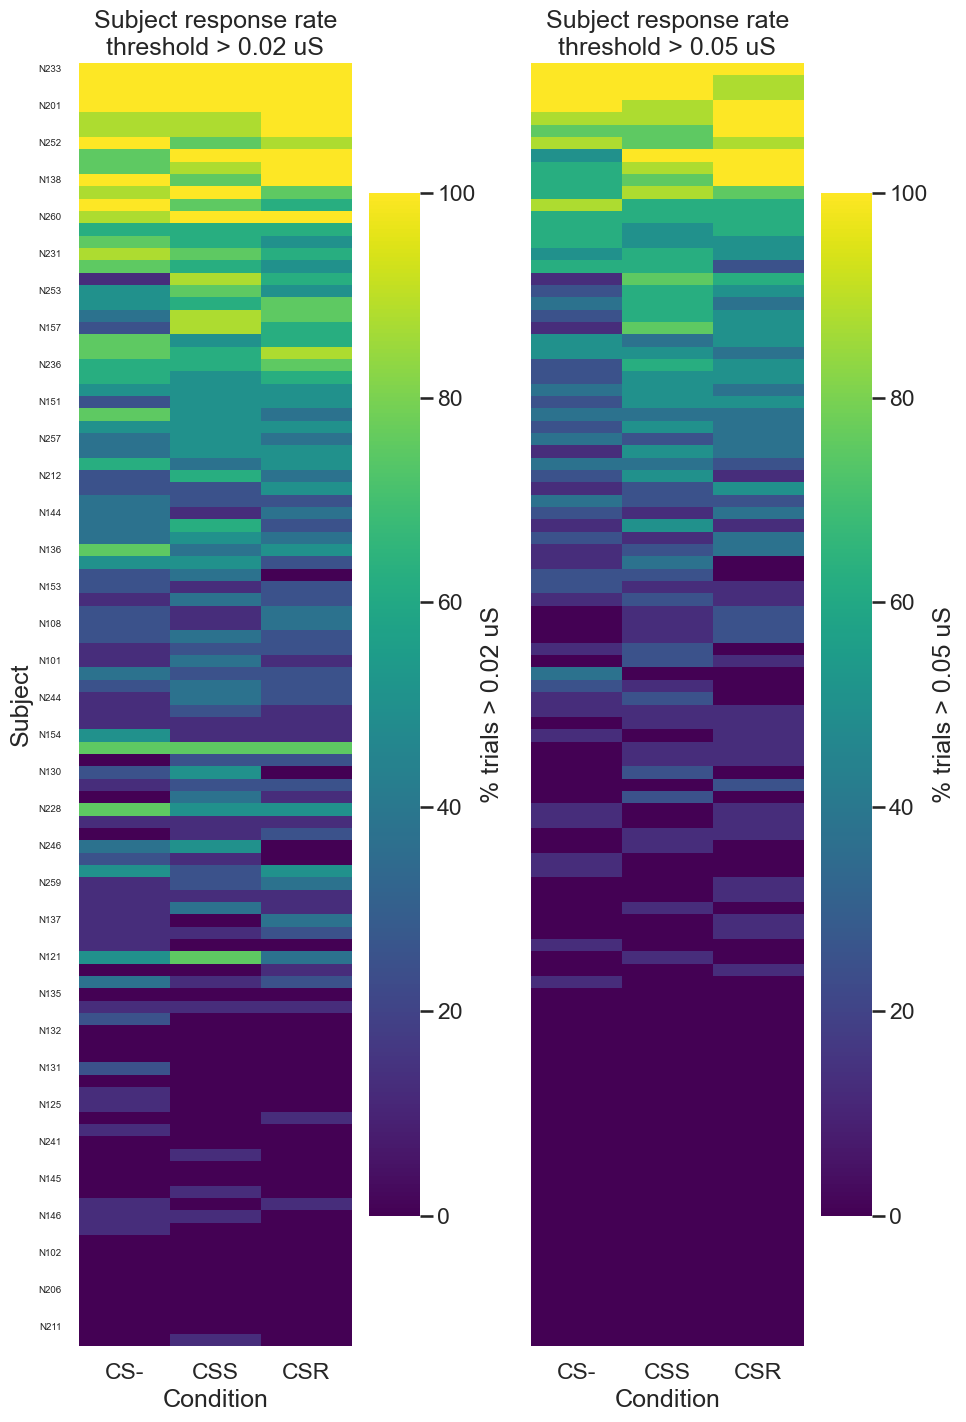

Saved figure -> /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_phase1_low_responder_rate_barplots.png


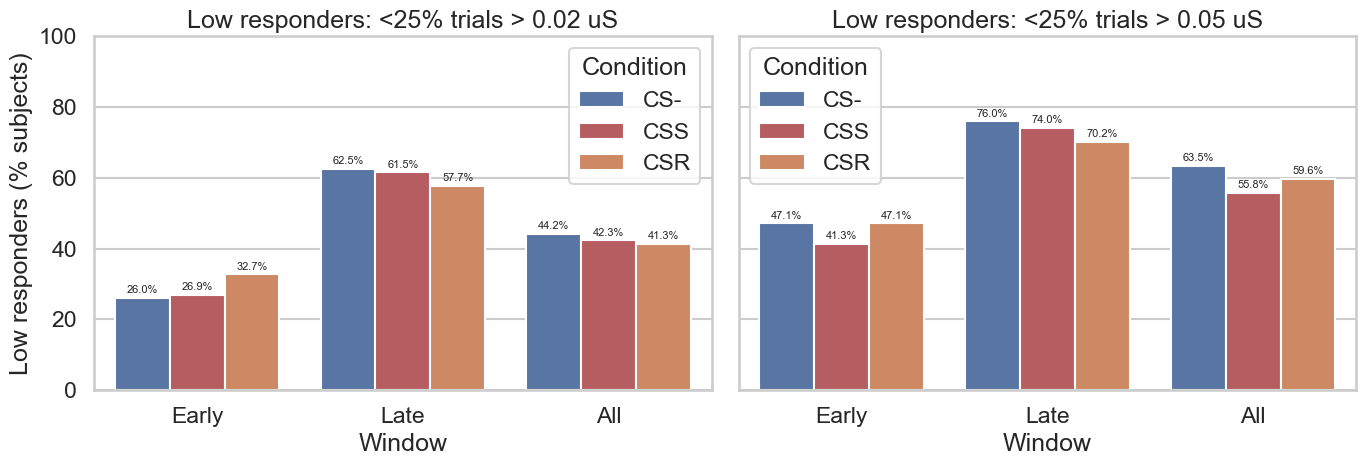

In [13]:
response_thresholds = [TRIAL_RESPONSE_THRESHOLD_RAW, PHYSIOLOGICAL_RESPONDER_THRESHOLD_RAW]
windows_for_response = ["Early", "Late", "All"]
profile_rows = []
for thr in response_thresholds:
    for subject, g_sub in acq.groupby("Subject"):
        for window in windows_for_response:
            g_win = g_sub if window == "All" else g_sub[g_sub["Window"] == window]
            for condition in CONDITION_ORDER:
                g = g_win[g_win["Condition"] == condition]
                n = len(g)
                n_resp = int((g[SCR_RAW_COL] > thr).sum())
                profile_rows.append({
                    "Subject": subject,
                    "threshold_uS": thr,
                    "Window": window,
                    "Condition": condition,
                    "n_trials": n,
                    "n_response_trials": n_resp,
                    "pct_response_trials": safe_percent(n_resp, n),
                    "low_responder": safe_percent(n_resp, n) < 100 * LOW_RESPONDER_RATE if n else np.nan,
                    "near_nonresponder": safe_percent(n_resp, n) < 100 * NEAR_NONRESPONDER_RATE if n else np.nan,
                })
subject_responder_profile = pd.DataFrame(profile_rows)
summary_rows = []
for keys, sub in subject_responder_profile.groupby(["threshold_uS", "Window", "Condition"], dropna=False):
    thr, window, condition = keys
    n_subjects = sub["Subject"].nunique()
    low_n = int(sub["low_responder"].sum())
    near_n = int(sub["near_nonresponder"].sum())
    summary_rows.append({
        "threshold_uS": thr,
        "Window": window,
        "Condition": condition,
        "n_subjects": n_subjects,
        "mean_pct_response": float(sub["pct_response_trials"].mean()),
        "median_pct_response": float(sub["pct_response_trials"].median()),
        "low_responder_n": low_n,
        "low_responder_percent": safe_percent(low_n, n_subjects),
        "near_nonresponder_n": near_n,
        "near_nonresponder_percent": safe_percent(near_n, n_subjects),
    })
subject_responder_summary = pd.DataFrame(summary_rows)
print("Subject-level response-rate summary")
display(subject_responder_summary)
heat_df = subject_responder_profile[(subject_responder_profile["Window"] == "All") & (subject_responder_profile["threshold_uS"].isin(response_thresholds))].copy()
sort_order = heat_df[heat_df["threshold_uS"] == PHYSIOLOGICAL_RESPONDER_THRESHOLD_RAW].groupby("Subject")["pct_response_trials"].mean().sort_values(ascending=False).index.tolist()
fig, axes = plt.subplots(1, len(response_thresholds), figsize=(10, max(10, 0.14 * len(sort_order))), sharey=True)
if len(response_thresholds) == 1:
    axes = [axes]
for ax, thr in zip(axes, response_thresholds):
    mat = heat_df[heat_df["threshold_uS"] == thr].pivot(index="Subject", columns="Condition", values="pct_response_trials").reindex(index=sort_order, columns=CONDITION_ORDER)
    sns.heatmap(mat, vmin=0, vmax=100, cmap="viridis", cbar_kws={"label": f"% trials > {thr:g} uS"}, ax=ax)
    ax.set_title(f"Subject response rate\nthreshold > {thr:g} uS")
    ax.set_xlabel("Condition")
    ax.set_ylabel("Subject" if ax is axes[0] else "")
    ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
save_current_fig("scr_phase1_subject_response_rate_heatmaps.png")
plt.show()
fig, axes = plt.subplots(1, len(response_thresholds), figsize=(14, 5), sharey=True)
if len(response_thresholds) == 1:
    axes = [axes]
for ax, thr in zip(axes, response_thresholds):
    sub = subject_responder_summary[subject_responder_summary["threshold_uS"] == thr].copy()
    sns.barplot(data=sub, x="Window", y="low_responder_percent", hue="Condition", order=windows_for_response, hue_order=CONDITION_ORDER, palette=CONDITION_PALETTE, ax=ax)
    ax.set_title(f"Low responders: <25% trials > {thr:g} uS")
    ax.set_ylabel("Low responders (% subjects)")
    ax.set_ylim(0, 100)
    for container in ax.containers:
        labels = [f"{v.get_height():.1f}%" if np.isfinite(v.get_height()) and v.get_height() > 0 else "" for v in container]
        ax.bar_label(container, labels=labels, fontsize=8, padding=2)
plt.tight_layout()
save_current_fig("scr_phase1_low_responder_rate_barplots.png")
plt.show()


## 6. Define Physiological Responders And Learners

Definitions used below:

- **Physiological SCR responder:** at least two acquisition CS+ trials with raw SCR >= 0.05 uS.
- **Simple acquisition differential learner:** physiological responder with mean thresholded-sqrt CS+ SCR greater than mean thresholded-sqrt CS- SCR across acquisition.
- **Habituation-adjusted learner:** physiological responder with a positive within-subject CS+ coefficient from `sqrtSCR ~ CSplus + Trial_Z`.
- **Late-phase sensitivity learner:** the earlier sensitivity rule: late CS+ > CS- and late discrimination greater than early discrimination.

In [14]:
def safe_mean(series):
    vals = pd.to_numeric(pd.Series(series), errors="coerce").dropna()
    return float(vals.mean()) if len(vals) else np.nan


def build_physiological_responder_flags(acq_df):
    rows = []
    for subject, g in acq_df.groupby("Subject"):
        csplus_raw = pd.to_numeric(g.loc[g["Domain"] == "CS+", SCR_RAW_COL], errors="coerce")
        css_raw = pd.to_numeric(g.loc[g["Condition"] == "CSS", SCR_RAW_COL], errors="coerce")
        csr_raw = pd.to_numeric(g.loc[g["Condition"] == "CSR", SCR_RAW_COL], errors="coerce")
        rows.append({
            "Subject": subject,
            "n_raw_CSplus_ge_0p05": int((csplus_raw >= PHYSIOLOGICAL_RESPONDER_THRESHOLD_RAW).sum()),
            "n_raw_CSS_ge_0p05": int((css_raw >= PHYSIOLOGICAL_RESPONDER_THRESHOLD_RAW).sum()),
            "n_raw_CSR_ge_0p05": int((csr_raw >= PHYSIOLOGICAL_RESPONDER_THRESHOLD_RAW).sum()),
        })
    out = pd.DataFrame(rows)
    out["physiological_responder_CSplus"] = out["n_raw_CSplus_ge_0p05"] >= PHYSIOLOGICAL_RESPONDER_MIN_CSPLUS_TRIALS
    out["physiological_responder_CSS"] = out["n_raw_CSS_ge_0p05"] >= PHYSIOLOGICAL_RESPONDER_MIN_CSPLUS_TRIALS
    out["physiological_responder_CSR"] = out["n_raw_CSR_ge_0p05"] >= PHYSIOLOGICAL_RESPONDER_MIN_CSPLUS_TRIALS
    return out


def build_simple_differential_flags(acq_df):
    rows = []
    for subject, g in acq_df.groupby("Subject"):
        csminus = g.loc[g["Condition"] == "CS-", SCR_SCORE_COL]
        csplus = g.loc[g["Domain"] == "CS+", SCR_SCORE_COL]
        css = g.loc[g["Condition"] == "CSS", SCR_SCORE_COL]
        csr = g.loc[g["Condition"] == "CSR", SCR_SCORE_COL]
        rows.append({
            "Subject": subject,
            "simple_diff_CSplus": safe_mean(csplus) - safe_mean(csminus),
            "simple_diff_CSS": safe_mean(css) - safe_mean(csminus),
            "simple_diff_CSR": safe_mean(csr) - safe_mean(csminus),
        })
    return pd.DataFrame(rows)


def subject_beta(g, target_condition=None):
    if target_condition is None:
        sub = g[g["Condition"].isin(CONDITION_ORDER)].copy()
        sub["CSplus_indicator"] = (sub["Domain"] == "CS+").astype(float)
        label = "CSplus"
    else:
        sub = g[g["Condition"].isin(["CS-", target_condition])].copy()
        sub["CSplus_indicator"] = (sub["Condition"] == target_condition).astype(float)
        label = target_condition
    y = pd.to_numeric(sub[SCR_SCORE_COL], errors="coerce").to_numpy(dtype=float)
    trial = pd.to_numeric(sub["stNum"], errors="coerce").to_numpy(dtype=float)
    x = sub["CSplus_indicator"].to_numpy(dtype=float)
    ok = np.isfinite(y) & np.isfinite(trial) & np.isfinite(x)
    y, trial, x = y[ok], trial[ok], x[ok]
    if len(y) < 4 or len(np.unique(x)) < 2:
        return {f"habituation_beta_{label}": np.nan, f"habituation_beta_trial_{label}": np.nan, f"habituation_n_{label}": int(len(y))}
    trial_z = (trial - trial.mean()) / trial.std(ddof=0) if trial.std(ddof=0) > 0 else np.zeros_like(trial)
    X = np.column_stack([np.ones(len(y)), x, trial_z])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    return {f"habituation_beta_{label}": float(beta[1]), f"habituation_beta_trial_{label}": float(beta[2]), f"habituation_n_{label}": int(len(y))}


def build_habituation_adjusted_flags(acq_df):
    rows = []
    for subject, g in acq_df.groupby("Subject"):
        row = {"Subject": subject}
        row.update(subject_beta(g, None))
        row.update(subject_beta(g, "CSS"))
        row.update(subject_beta(g, "CSR"))
        rows.append(row)
    return pd.DataFrame(rows)


def build_late_phase_sensitivity_flags(acq_df):
    rows = []
    for subject, g in acq_df.groupby("Subject"):
        row = {"Subject": subject}
        for label, mask in {"CSplus": g["Domain"] == "CS+", "CSS": g["Condition"] == "CSS", "CSR": g["Condition"] == "CSR"}.items():
            target = g[mask]
            base = g[g["Condition"] == "CS-"]
            target_early = target[target["Window"] == "Early"][SCR_SCORE_COL]
            target_late = target[target["Window"] == "Late"][SCR_SCORE_COL]
            base_early = base[base["Window"] == "Early"][SCR_SCORE_COL]
            base_late = base[base["Window"] == "Late"][SCR_SCORE_COL]
            early_diff = safe_mean(target_early) - safe_mean(base_early)
            late_diff = safe_mean(target_late) - safe_mean(base_late)
            row[f"late_phase_diff_early_{label}"] = early_diff
            row[f"late_phase_diff_late_{label}"] = late_diff
            row[f"late_phase_diff_change_{label}"] = late_diff - early_diff
            row[f"late_phase_learner_{label}"] = (late_diff > 0) and ((late_diff - early_diff) > 0)
        rows.append(row)
    return pd.DataFrame(rows)

physio_flags = build_physiological_responder_flags(acq)
simple_flags = build_simple_differential_flags(acq)
habituation_flags = build_habituation_adjusted_flags(acq)
late_phase_flags = build_late_phase_sensitivity_flags(acq)

learn_df = physio_flags.merge(simple_flags, on="Subject", how="outer").merge(habituation_flags, on="Subject", how="outer").merge(late_phase_flags, on="Subject", how="outer")

for label in ["CSplus", "CSS", "CSR"]:
    learn_df[f"simple_learner_{label}"] = learn_df["physiological_responder_CSplus"] & (learn_df[f"simple_diff_{label}"] > 0)
    learn_df[f"habituation_adjusted_learner_{label}"] = learn_df["physiological_responder_CSplus"] & (learn_df[f"habituation_beta_{label}"] > 0)
    learn_df[f"late_phase_sensitivity_learner_{label}"] = learn_df[f"late_phase_learner_{label}"].astype(bool)

for prefix in ["simple_learner", "habituation_adjusted_learner", "late_phase_sensitivity_learner"]:
    learn_df[f"{prefix}_either_CSS_or_CSR"] = learn_df[[f"{prefix}_CSS", f"{prefix}_CSR"]].any(axis=1)
    learn_df[f"{prefix}_both_CSS_and_CSR"] = learn_df[[f"{prefix}_CSS", f"{prefix}_CSR"]].all(axis=1)

if META_PATH.exists():
    meta = pd.read_csv(META_PATH)
    meta["Subject"] = meta["subject_id"].astype(str).str.strip()
    keep = [c for c in ["Subject", "Group", "Drug", "drug_condition", "Gender", "gender_code", "demo_age", "guess"] if c in meta.columns]
    learn_df = learn_df.merge(meta[keep], on="Subject", how="left")
else:
    learn_df["Group"] = np.nan
    learn_df["Drug"] = np.nan

print("Learner table preview")
display(learn_df.head(20))


Learner table preview


,Subject,n_raw_CSplus_ge_0p05,n_raw_CSS_ge_0p05,n_raw_CSR_ge_0p05,physiological_responder_CSplus,physiological_responder_CSS,physiological_responder_CSR,simple_diff_CSplus,simple_diff_CSS,simple_diff_CSR,habituation_beta_CSplus,habituation_beta_trial_CSplus,habituation_n_CSplus,habituation_beta_CSS,habituation_beta_trial_CSS,habituation_n_CSS,habituation_beta_CSR,habituation_beta_trial_CSR,habituation_n_CSR,late_phase_diff_early_CSplus,late_phase_diff_late_CSplus,late_phase_diff_change_CSplus,late_phase_learner_CSplus,late_phase_diff_early_CSS,late_phase_diff_late_CSS,late_phase_diff_change_CSS,late_phase_learner_CSS,late_phase_diff_early_CSR,late_phase_diff_late_CSR,late_phase_diff_change_CSR,late_phase_learner_CSR,simple_learner_CSplus,habituation_adjusted_learner_CSplus,late_phase_sensitivity_learner_CSplus,simple_learner_CSS,habituation_adjusted_learner_CSS,late_phase_sensitivity_learner_CSS,simple_learner_CSR,habituation_adjusted_learner_CSR,late_phase_sensitivity_learner_CSR,simple_learner_either_CSS_or_CSR,simple_learner_both_CSS_and_CSR,habituation_adjusted_learner_either_CSS_or_CSR,habituation_adjusted_learner_both_CSS_and_CSR,late_phase_sensitivity_learner_either_CSS_or_CSR,late_phase_sensitivity_learner_both_CSS_and_CSR,Group,Drug,drug_condition,Gender,gender_code,demo_age,guess
0,N101,3,2,1,True,True,False,0.041632,0.079419,0.003846,0.036059,-0.025719,24,0.071397,-0.050826,16,0.009078,0.018085,16,0.105935,-0.022671,-0.128606,False,0.211870,-0.053033,-0.264903,False,0.000000,0.007692,0.007692,True,True,True,False,True,True,False,True,True,True,True,True,True,True,True,False,SAD,Placebo,0,Female,0,21,0.0
1,N102,0,0,0,False,False,False,0.000000,0.000000,0.000000,0.000000,0.000000,24,0.000000,0.000000,16,0.000000,0.000000,16,0.000000,0.000000,0.000000,False,0.000000,0.000000,0.000000,False,0.000000,0.000000,0.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,SAD,Oxytocin,1,Male,1,25,NaN
2,N103,14,6,8,True,True,True,0.010143,-0.011383,0.031670,-0.001815,-0.055183,24,-0.022717,-0.071810,16,0.020399,-0.038953,16,-0.012321,0.032607,0.044928,True,0.003405,-0.026172,-0.029578,False,-0.028047,0.091386,0.119433,True,True,False,True,False,False,False,True,True,True,True,False,True,False,True,False,SAD,Oxytocin,1,Female,0,23,0.0
3,N104,0,0,0,False,False,False,-0.018114,-0.018114,-0.018114,-0.020120,-0.009256,24,-0.020233,-0.013425,16,-0.022451,-0.014989,16,-0.036228,0.000000,0.036228,False,-0.036228,0.000000,0.036228,False,-0.036228,0.000000,0.036228,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,SAD,Oxytocin,1,Male,1,33,0.0
4,N105,0,0,0,False,False,False,0.000000,0.000000,0.000000,0.000000,0.000000,24,0.000000,0.000000,16,0.000000,0.000000,16,0.000000,0.000000,0.000000,False,0.000000,0.000000,0.000000,False,0.000000,0.000000,0.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,SAD,Oxytocin,1,Female,0,21,0.0
5,N106,0,0,0,False,False,False,0.000000,0.000000,0.000000,0.000000,0.000000,24,0.000000,0.000000,16,0.000000,0.000000,16,0.000000,0.000000,0.000000,False,0.000000,0.000000,0.000000,False,0.000000,0.000000,0.000000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,SAD,Oxytocin,1,Female,0,22,0.0
6,N108,3,1,2,True,False,True,0.023041,-0.012821,0.058904,0.011395,-0.053745,24,-0.017445,-0.029299,16,0.037338,-0.074537,16,0.046083,0.000000,-0.046083,False,-0.025642,0.000000,0.025642,False,0.117808,0.000000,-0.117808,False,True,True,False,False,False,False,True,True,False,True,False,True,False,False,False,SAD,Oxytocin,1,Male,1,22,1.0
7,N109,3,1,2,True,False,True,0.020950,0.028832,0.013068,0.010629,-0.047629,24,0.021495,-0.046489,16,-0.002757,-0.054695,16,0.022535,0.019365,-0.003170,False,0.018935,0.038730,0.019795,True,0.026136,0.000000,-0.026136,False,True,True,False,True,True,True,True,False,False,True,True,True,False,True,False,SAD,O

## 7. Learner Rates And Visualization

The most interpretable rates are shown both as percent of the full sample and percent of physiological SCR responders.

Overall learner rates


,Definition,N_total,N_physiological_responder,N_learned,Percent_of_total,Percent_of_responders
0,Physiological SCR responder,104,59,59,56.730769,100.000000
1,Simple acquisition differential: pooled CS+ > CS-,104,59,41,39.423077,69.491525
2,Simple acquisition differential: CSS > CS-,104,59,43,41.346154,72.881356
3,Simple acquisition differential: CSR > CS-,104,59,37,35.576923,62.711864
4,Simple acquisition differential: either CSS or...,104,59,50,48.076923,84.745763
5,Simple acquisition differential: both CSS and CSR,104,59,30,28.846154,50.847458
6,Habituation-adjusted beta: pooled CS+ > CS-,104,59,32,30.769231,54.237288
7,Habituation-adjusted beta: CSS > CS-,104,59,33,31.730769,55.932203
8,Habituation-adjusted beta: CSR > CS-,104,59,27,25.961538,45.762712
9,Habituation-adjusted beta: either CSS or CSR,104,59,39,37.500000,66.101695


Learner rates by Group


,Group,Definition,N_total,N_physiological_responder,N_learned,Percent_of_total,Percent_of_responders
0,HC,Physiological SCR responder,53,32,32,60.377358,100.000000
1,HC,Simple acquisition differential: pooled CS+ > CS-,53,32,21,39.622642,65.625000
2,HC,Simple acquisition differential: CSS > CS-,53,32,26,49.056604,81.250000
3,HC,Simple acquisition differential: CSR > CS-,53,32,18,33.962264,56.250000
4,HC,Simple acquisition differential: either CSS or...,53,32,27,50.943396,84.375000
5,HC,Simple acquisition differential: both CSS and CSR,53,32,17,32.075472,53.125000
6,HC,Habituation-adjusted beta: pooled CS+ > CS-,53,32,15,28.301887,46.875000
7,HC,Habituation-adjusted beta: CSS > CS-,53,32,17,32.075472,53.125000
8,HC,Habituation-adjusted beta: CSR > CS-,53,32,12,22.641509,37.500000
9,HC,Habituation-adjusted beta: either CSS or CSR,53,32,18,33.962264,56.250000


Learner rates by Group x Drug


,Group,Drug,Definition,N_total,N_physiological_responder,N_learned,Percent_of_total,Percent_of_responders
0,HC,Oxytocin,Physiological SCR responder,24,13,13,54.166667,100.000000
1,HC,Oxytocin,Simple acquisition differential: pooled CS+ > CS-,24,13,8,33.333333,61.538462
2,HC,Oxytocin,Simple acquisition differential: CSS > CS-,24,13,11,45.833333,84.615385
3,HC,Oxytocin,Simple acquisition differential: CSR > CS-,24,13,8,33.333333,61.538462
4,HC,Oxytocin,Simple acquisition differential: either CSS or...,24,13,12,50.000000,92.307692
5,HC,Oxytocin,Simple acquisition differential: both CSS and CSR,24,13,7,29.166667,53.846154
6,HC,Oxytocin,Habituation-adjusted beta: pooled CS+ > CS-,24,13,5,20.833333,38.461538
7,HC,Oxytocin,Habituation-adjusted beta: CSS > CS-,24,13,7,29.166667,53.846154
8,HC,Oxytocin,Habituation-adjusted beta: CSR > CS-,24,13,4,16.666667,30.769231
9,HC,Oxytocin,Habituation-adjusted beta: either CSS or CSR,24,13,7,29.166667,53.846154


Saved figure -> /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_phase1_responder_learner_rates_by_group.png


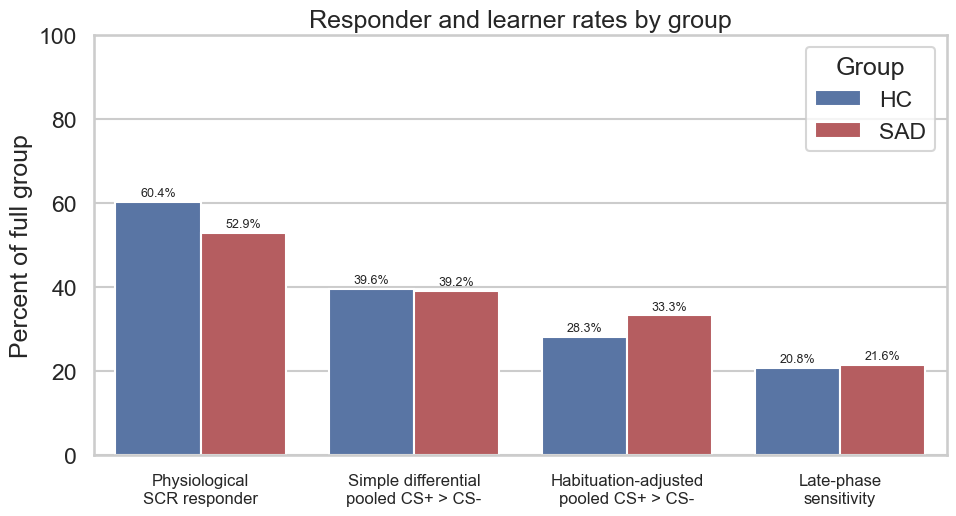

In [15]:
def summarize_definitions(df, by=None):
    definitions = [
        ("Physiological SCR responder", "physiological_responder_CSplus"),
        ("Simple acquisition differential: pooled CS+ > CS-", "simple_learner_CSplus"),
        ("Simple acquisition differential: CSS > CS-", "simple_learner_CSS"),
        ("Simple acquisition differential: CSR > CS-", "simple_learner_CSR"),
        ("Simple acquisition differential: either CSS or CSR", "simple_learner_either_CSS_or_CSR"),
        ("Simple acquisition differential: both CSS and CSR", "simple_learner_both_CSS_and_CSR"),
        ("Habituation-adjusted beta: pooled CS+ > CS-", "habituation_adjusted_learner_CSplus"),
        ("Habituation-adjusted beta: CSS > CS-", "habituation_adjusted_learner_CSS"),
        ("Habituation-adjusted beta: CSR > CS-", "habituation_adjusted_learner_CSR"),
        ("Habituation-adjusted beta: either CSS or CSR", "habituation_adjusted_learner_either_CSS_or_CSR"),
        ("Habituation-adjusted beta: both CSS and CSR", "habituation_adjusted_learner_both_CSS_and_CSR"),
        ("Late-phase sensitivity: pooled CS+", "late_phase_sensitivity_learner_CSplus"),
        ("Late-phase sensitivity: CSS", "late_phase_sensitivity_learner_CSS"),
        ("Late-phase sensitivity: CSR", "late_phase_sensitivity_learner_CSR"),
        ("Late-phase sensitivity: either CSS or CSR", "late_phase_sensitivity_learner_either_CSS_or_CSR"),
        ("Late-phase sensitivity: both CSS and CSR", "late_phase_sensitivity_learner_both_CSS_and_CSR"),
    ]
    groups = [((), df)] if by is None else list(df.groupby(by, dropna=False))
    rows = []
    for key, sub in groups:
        base = {}
        if by is not None:
            key_tuple = key if isinstance(key, tuple) else (key,)
            base = dict(zip(by, key_tuple))
        n_total = len(sub)
        n_resp = int(sub["physiological_responder_CSplus"].sum())
        for definition, flag in definitions:
            n = int(sub[flag].sum())
            row = dict(base)
            row.update({
                "Definition": definition,
                "N_total": n_total,
                "N_physiological_responder": n_resp,
                "N_learned": n,
                "Percent_of_total": safe_percent(n, n_total),
                "Percent_of_responders": safe_percent(n, n_resp),
            })
            rows.append(row)
    return pd.DataFrame(rows)
learner_summary = summarize_definitions(learn_df)
learner_by_group = summarize_definitions(learn_df, by=["Group"]) if "Group" in learn_df.columns else pd.DataFrame()
learner_by_group_drug = summarize_definitions(learn_df, by=["Group", "Drug"]) if {"Group", "Drug"}.issubset(learn_df.columns) else pd.DataFrame()
print("Overall learner rates")
display(learner_summary)
print("Learner rates by Group")
display(learner_by_group)
print("Learner rates by Group x Drug")
display(learner_by_group_drug)
key_defs = [
    "Physiological SCR responder",
    "Simple acquisition differential: pooled CS+ > CS-",
    "Habituation-adjusted beta: pooled CS+ > CS-",
    "Late-phase sensitivity: pooled CS+",
]
plot_df = learner_by_group[learner_by_group["Definition"].isin(key_defs)].copy()
label_map = {
    "Physiological SCR responder": "Physiological\nSCR responder",
    "Simple acquisition differential: pooled CS+ > CS-": "Simple differential\npooled CS+ > CS-",
    "Habituation-adjusted beta: pooled CS+ > CS-": "Habituation-adjusted\npooled CS+ > CS-",
    "Late-phase sensitivity: pooled CS+": "Late-phase\nsensitivity",
}
plot_df["DisplayDefinition"] = plot_df["Definition"].map(label_map)
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=plot_df, x="DisplayDefinition", y="Percent_of_total", hue="Group", palette=GROUP_PALETTE, ax=ax)
ax.set_title("Responder and learner rates by group")
ax.set_ylabel("Percent of full group")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0, pad=4, labelsize=12)
for tick in ax.get_xticklabels():
    tick.set_ha("center")
for container in ax.containers:
    labels = [f"{v.get_height():.1f}%" if np.isfinite(v.get_height()) and v.get_height() > 0 else "" for v in container]
    ax.bar_label(container, labels=labels, fontsize=9, padding=2)
plt.subplots_adjust(bottom=0.18)
save_current_fig("scr_phase1_responder_learner_rates_by_group.png")
plt.show()


## 8. Save Clean Outputs

The saved files are intended to be used for sensitivity analyses in downstream neural MVPA summaries.

In [16]:
learn_df_path = OUT_DIR / "scr_acquisition_fear_learning_subjects.csv"
learner_summary_path = OUT_DIR / "scr_acquisition_new_recommended_learner_summary.csv"
learner_by_group_path = OUT_DIR / "scr_acquisition_new_recommended_learner_by_group.csv"
learner_by_group_drug_path = OUT_DIR / "scr_acquisition_new_recommended_learner_by_group_drug.csv"
subject_responder_profile_path = OUT_DIR / "scr_acquisition_subject_responder_profile.csv"
subject_responder_summary_path = OUT_DIR / "scr_acquisition_subject_responder_summary.csv"
floor_summary_path = OUT_DIR / "scr_acquisition_floor_summary.csv"
habituation_summary_path = OUT_DIR / "scr_acquisition_habituation_summary.csv"
habituation_tests_path = OUT_DIR / "scr_acquisition_habituation_paired_tests.csv"
floor_effect_tests_path = OUT_DIR / "scr_acquisition_floor_effect_paired_tests.csv"
physiological_responder_list_path = OUT_DIR / "scr_acquisition_physiological_responder_subjects.txt"
simple_learner_list_path = OUT_DIR / "scr_acquisition_simple_differential_CSplus_learner_subjects.txt"
habituation_adjusted_learner_list_path = OUT_DIR / "scr_acquisition_habituation_adjusted_CSplus_learner_subjects.txt"
late_phase_learner_list_path = OUT_DIR / "scr_acquisition_late_phase_sensitivity_CSplus_learner_subjects.txt"
learn_df.to_csv(learn_df_path, index=False)
learner_summary.to_csv(learner_summary_path, index=False)
learner_by_group.to_csv(learner_by_group_path, index=False)
learner_by_group_drug.to_csv(learner_by_group_drug_path, index=False)
subject_responder_profile.to_csv(subject_responder_profile_path, index=False)
subject_responder_summary.to_csv(subject_responder_summary_path, index=False)
floor_summary.to_csv(floor_summary_path, index=False)
habituation_summary.to_csv(habituation_summary_path, index=False)
habituation_tests.to_csv(habituation_tests_path, index=False)
floor_effect_tests.to_csv(floor_effect_tests_path, index=False)
physiological_responder_subjects = learn_df.loc[learn_df["physiological_responder_CSplus"], "Subject"].tolist()
simple_learner_subjects = learn_df.loc[learn_df["simple_learner_CSplus"], "Subject"].tolist()
habituation_adjusted_learner_subjects = learn_df.loc[learn_df["habituation_adjusted_learner_CSplus"], "Subject"].tolist()
late_phase_learner_subjects = learn_df.loc[learn_df["late_phase_sensitivity_learner_CSplus"], "Subject"].tolist()
physiological_responder_list_path.write_text("\n".join(physiological_responder_subjects) + ("\n" if physiological_responder_subjects else ""))
simple_learner_list_path.write_text("\n".join(simple_learner_subjects) + ("\n" if simple_learner_subjects else ""))
habituation_adjusted_learner_list_path.write_text("\n".join(habituation_adjusted_learner_subjects) + ("\n" if habituation_adjusted_learner_subjects else ""))
late_phase_learner_list_path.write_text("\n".join(late_phase_learner_subjects) + ("\n" if late_phase_learner_subjects else ""))
print("Saved outputs:")
for path in [learn_df_path, learner_summary_path, learner_by_group_path, learner_by_group_drug_path, subject_responder_profile_path, subject_responder_summary_path, floor_summary_path, habituation_summary_path, habituation_tests_path, floor_effect_tests_path, physiological_responder_list_path, simple_learner_list_path, habituation_adjusted_learner_list_path, late_phase_learner_list_path]:
    print("-", path)


Saved outputs:
- /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_acquisition_fear_learning_subjects.csv
- /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_acquisition_new_recommended_learner_summary.csv
- /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_acquisition_new_recommended_learner_by_group.csv
- /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_acquisition_new_recommended_learner_by_group_drug.csv
- /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_acquisition_subject_responder_profile.csv
- /Users/xiaoqianxiao/projects/NARSAD/MRI/derivatives/fMRI_analysis/LSS/results/fear_learning_scr_phase1_sqrt_4trial/scr_acquisition_subject_respond